In [11]:

CFG = {
    # ── Paths ─────────────────────────────────────────────────────────────────
    "train_dir"      : "Project/MRI_DATA/BraTS2021_Training_Data_2D/train",
    "val_dir"        : "Project/MRI_DATA/BraTS2021_Training_Data_2D/val",
    "test_dir"       : "Project/MRI_DATA/BraTS2021_Training_Data_2D/test",
    "diffusion_ckpt" : "output_mdn_mrm_updateed/run3/checkpoints/best_G.pt",
    "output_dir"     : "./ccunet_outputs/run1",
    "resume_ckpt"    : None,

    # ── SC_MDN config (must match training) ───────────────────────────────────
    "latent_dim"       : 768,
    "hidden_dim"       : 768,
    "num_classes"      : 2,
    "max_time_steps"   : 200,
    "n_blocks"         : 4,
    "n_sampling_steps" : 100,

    # ── Dataset ───────────────────────────────────────────────────────────────
    "img_size"    : 128,
    "num_workers" : 0,
    # per modality per split: train=5000+5000, val=1000+1000, test=2000+2000
    "max_samples" : {"train": 5000, "val": 1000, "test": 2000},

    # ── U-Net architecture ────────────────────────────────────────────────────
    "base_channels" : 64,
    "depth"         : 4,

    # ── Training ──────────────────────────────────────────────────────────────
    "epochs"      : 100,
    "batch_size"  : 8,
    "lr"          : 1e-4,
    "lambda_ssim" : 0.5,

    # ── SSIM kernel ───────────────────────────────────────────────────────────
    "ssim_kernel_size" : 11,
    "ssim_sigma"       : 1.5,
}

In [12]:
import os, re, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
gpu_available = torch.cuda.is_available()
print(f"GPU Available: {gpu_available}")

if gpu_available:
    # Get the exact name of the GPU
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    # Get the number of GPUs
    print(f"GPU Count: {torch.cuda.device_count()}")


Device: cuda
GPU Available: True
GPU Name: NVIDIA A30 MIG 2g.12gb
GPU Count: 1


In [13]:
def sinusoidal_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    assert dim % 2 == 0
    half  = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, dtype=torch.float32, device=timesteps.device) / half
    )
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


class SC_MDN_Block(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.feature_mlp1 = nn.Sequential(nn.LayerNorm(hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.time_mlp     = nn.Sequential(nn.LayerNorm(hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.style_mlp    = nn.Sequential(nn.LayerNorm(hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.feature_mlp2 = nn.Sequential(nn.LayerNorm(hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))

    def forward(self, x, t_emb, s_emb):
        h   = self.feature_mlp1(x)
        out = self.feature_mlp2(h + self.time_mlp(t_emb) + self.style_mlp(s_emb))
        return x + out


class SC_MDN(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=768, num_classes=2, max_time_steps=30, n_blocks=4):
        super().__init__()
        self.hidden_dim      = hidden_dim
        self.max_time_steps  = max_time_steps
        self.input_linear1   = nn.Linear(input_dim, hidden_dim)
        self.input_linear2   = nn.Linear(input_dim, hidden_dim)
        self.input_fuse      = nn.Linear(hidden_dim * 2, hidden_dim)
        self.time_mlp        = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.style_dict      = nn.Embedding(num_classes, hidden_dim)
        self.blocks          = nn.ModuleList([SC_MDN_Block(hidden_dim) for _ in range(n_blocks)])
        self.output_linear   = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, class_labels, timesteps):
        h     = self.input_fuse(torch.cat([self.input_linear1(x), self.input_linear2(x)], dim=-1))
        t_emb = self.time_mlp(sinusoidal_embedding(timesteps, self.hidden_dim))
        s_emb = self.style_dict(class_labels)
        for block in self.blocks:
            h = block(h, t_emb, s_emb)
        return self.output_linear(h)


def _build_noise_schedule(max_time_steps, device):
    betas               = torch.linspace(1e-4, 0.02, max_time_steps, device=device)
    alphas_cumprod      = torch.cumprod(1.0 - betas, dim=0)
    alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]])
    return alphas_cumprod, alphas_cumprod_prev


def _ddim_step(y_t, y_0_pred, a_t, a_t_prev, eta=0.0):
    sigma_t    = eta * torch.sqrt(((1 - a_t_prev) / (1 - a_t)) * (1 - a_t / a_t_prev).clamp(min=0.0))
    pred_noise = (y_t - torch.sqrt(a_t) * y_0_pred) / (torch.sqrt(1 - a_t) + 1e-8)
    dir_yt     = torch.sqrt((1 - a_t_prev - sigma_t ** 2).clamp(min=0.0)) * pred_noise
    noise      = torch.randn_like(y_t) if eta > 0 else torch.zeros_like(y_t)
    return torch.sqrt(a_t_prev) * y_0_pred + dir_yt + sigma_t * noise


@torch.no_grad()
def generate_embeddings(sc_mdn, target_class, n_samples, cfg, gen_device):
    """DDIM reverse diffusion → (n_samples, 768) target distribution embeddings."""
    sc_mdn.eval()
    alphas_cumprod, alphas_cumprod_prev = _build_noise_schedule(cfg["max_time_steps"], gen_device)
    step_indices = torch.linspace(
        0, cfg["max_time_steps"] - 1, cfg["n_sampling_steps"], dtype=torch.long, device=gen_device
    ).flip(0)

    labels = torch.full((n_samples,), target_class, dtype=torch.long, device=gen_device)
    y_t    = torch.randn(n_samples, cfg["latent_dim"], device=gen_device)

    for t_idx in step_indices:
        y_0_pred = sc_mdn(y_t, labels, t_idx.expand(n_samples))
        y_t      = _ddim_step(y_t, y_0_pred, alphas_cumprod[t_idx], alphas_cumprod_prev[t_idx])

    return y_t.cpu()   # (n_samples, 768)



In [14]:
class BraTSTripletsDataset(Dataset):
    """
    Returns (flair_tensor, target_tensor, embedding_tensor) per item.
    Naming: BraTS2021_{patient_id}_{modality}_slice_{slice_num}.png
    """
    MODALITY_TO_CLASS = {"t1": 0, "t2": 1}

    def __init__(self, image_dir, target_modality, sc_mdn, cfg, gen_device, max_samples=None):
        assert target_modality in ("t1", "t2")
        self.triplets = []

        pattern = re.compile(r"BraTS2021_(\d+)_(flair|t1|t2|t1ce)_slice_(\d+)\.png", re.IGNORECASE)
        index   = {}
        for fname in os.listdir(image_dir):
            m = pattern.match(fname)
            if not m:
                continue
            key = (m.group(1), m.group(3))
            index.setdefault(key, {})[m.group(2).lower()] = os.path.join(image_dir, fname)

        for key, mods in index.items():
            if "flair" in mods and target_modality in mods:
                self.triplets.append((mods["flair"], mods[target_modality]))

        # Truncate to max_samples if specified
        if max_samples is not None:
            self.triplets = self.triplets[:max_samples]

        print(f"  [{target_modality.upper()}] {len(self.triplets)} pairs loaded"
              + (f" (capped at {max_samples})" if max_samples is not None else ""))

        if not self.triplets:
            raise RuntimeError(f"No FLAIR↔{target_modality} pairs in {image_dir}")

        self.img_transform = transforms.Compose([
            transforms.Resize((cfg["img_size"], cfg["img_size"])),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),                        # [0, 1]
            transforms.Normalize(mean=[0.5], std=[0.5]),  # [-1, 1]
        ])

        # Pre-generate one unique embedding per sample
        target_class = self.MODALITY_TO_CLASS[target_modality]
        n, chunk     = len(self.triplets), 256
        sc_mdn       = sc_mdn.to(gen_device)
        print(f"  [{target_modality.upper()}] Generating {n} embeddings via DDIM ...")
        all_embs = []
        for start in range(0, n, chunk):
            end  = min(start + chunk, n)
            embs = generate_embeddings(sc_mdn, target_class, end - start, cfg, gen_device)
            all_embs.append(embs)
            print(f"    {end}/{n}")
        self.embeddings = torch.cat(all_embs, dim=0)   # (N, 768) on CPU

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        flair_path, target_path = self.triplets[idx]
        flair  = self.img_transform(Image.open(flair_path).convert("L"))
        target = self.img_transform(Image.open(target_path).convert("L"))
        return flair, target, self.embeddings[idx]


def build_dataset(image_dir, sc_mdn, cfg, gen_device, max_samples=None):
    print(f"\n  Building T1 pairs from {image_dir}")
    ds_t1 = BraTSTripletsDataset(image_dir, "t1", sc_mdn, cfg, gen_device, max_samples=max_samples)
    print(f"\n  Building T2 pairs from {image_dir}")
    ds_t2 = BraTSTripletsDataset(image_dir, "t2", sc_mdn, cfg, gen_device, max_samples=max_samples)
    combined = ConcatDataset([ds_t1, ds_t2])
    print(f"  Total: {len(combined)} ({len(ds_t1)} T1 + {len(ds_t2)} T2)")
    return combined

In [15]:


class EmbeddingProjector(nn.Module):
    """Linear → SiLU → Linear  (matches Fig. 3B target-distribution branch)."""
    def __init__(self, emb_dim, out_channels):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, out_channels),
            nn.SiLU(),
            nn.Linear(out_channels, out_channels),
        )

    def forward(self, emb):
        return self.mlp(emb)   # (B, out_channels)


class InjectionConvBlock(nn.Module):
    """
    Input feature branch (Fig. 3B):
        x → GroupNorm → SiLU → Conv2d → + projected_embedding → output
    plus a residual skip from x.
    """
    def __init__(self, in_channels, out_channels, emb_dim=768, num_groups=8):
        super().__init__()
        self.norm      = nn.GroupNorm(min(num_groups, in_channels), in_channels)
        self.act       = nn.SiLU()
        self.conv      = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.emb_proj  = EmbeddingProjector(emb_dim, out_channels)
        self.res_conv  = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, emb):
        h = self.conv(self.act(self.norm(x)))                   # (B, C_out, H, W)
        e = self.emb_proj(emb).unsqueeze(-1).unsqueeze(-1)      # (B, C_out, 1,  1)
        return h + e + self.res_conv(x)


class DoubleConvBlock(nn.Module):
    """Two sequential InjectionConvBlocks — embedding injected at both."""
    def __init__(self, in_channels, out_channels, emb_dim=768):
        super().__init__()
        self.b1 = InjectionConvBlock(in_channels,  out_channels, emb_dim)
        self.b2 = InjectionConvBlock(out_channels, out_channels, emb_dim)

    def forward(self, x, emb):
        return self.b2(self.b1(x, emb), emb)


class EncoderStage(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim=768):
        super().__init__()
        self.conv = DoubleConvBlock(in_channels, out_channels, emb_dim)
        self.down = nn.MaxPool2d(2)

    def forward(self, x, emb):
        skip = self.conv(x, emb)     # full-res feature for skip connection
        return skip, self.down(skip) # skip, downsampled


class DecoderStage(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim=768):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConvBlock(in_channels, out_channels, emb_dim)

    def forward(self, x, skip, emb):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=True)
        return self.conv(torch.cat([x, skip], dim=1), emb)


class CrossConditionalUNet(nn.Module):
    """
    FLAIR → T1 / T2 translation conditioned on a 768-dim target distribution
    embedding from SC_MDN.  Embedding is injected at every encoder and decoder
    stage (before downsampling and after upsampling), as in Fig. 3B.

    Channel widths with base_channels=64, depth=4:
        Encoder    : 64 → 128 → 256 → 512
        Bottleneck : 512 → 1024
        Decoder    : (1024+512)→512 → (512+256)→256 → (256+128)→128 → (128+64)→64
    """
    def __init__(self, in_channels=1, out_channels=1, base_channels=64, emb_dim=768, depth=4):
        super().__init__()
        enc_ch = [base_channels * (2 ** i) for i in range(depth)]   # [64,128,256,512]

        self.encoders   = nn.ModuleList()
        ch_in = in_channels
        for ch_out in enc_ch:
            self.encoders.append(EncoderStage(ch_in, ch_out, emb_dim))
            ch_in = ch_out

        self.bottleneck = DoubleConvBlock(enc_ch[-1], enc_ch[-1] * 2, emb_dim)

        self.decoders = nn.ModuleList()
        ch_in = enc_ch[-1] * 2
        for ch_skip in reversed(enc_ch):
            self.decoders.append(DecoderStage(ch_in + ch_skip, ch_skip, emb_dim))
            ch_in = ch_skip

        self.out_conv = nn.Conv2d(enc_ch[0], out_channels, kernel_size=1)

    def forward(self, x, emb):
        """
        x  : (B, 1, H, W)  FLAIR, normalised to [-1, 1]
        emb: (B, 768)       target distribution embedding from SC_MDN
        returns (B, 1, H, W) in [-1, 1]
        """
        skips, h = [], x
        for enc in self.encoders:
            skip, h = enc(h, emb)
            skips.append(skip)

        h = self.bottleneck(h, emb)

        for dec, skip in zip(self.decoders, reversed(skips)):
            h = dec(h, skip, emb)

        return self.out_conv(h)


In [16]:

def _gaussian_kernel_2d(kernel_size=11, sigma=1.5, device="cpu"):
    x = torch.arange(kernel_size, dtype=torch.float32, device=device) - kernel_size // 2
    g = torch.exp(-x ** 2 / (2 * sigma ** 2))
    g = g / g.sum()
    k = g.outer(g).unsqueeze(0).unsqueeze(0)   # (1, 1, k, k)
    return k


def ssim_loss(pred, target, kernel):
    """
    Returns 1 - SSIM.  pred / target in [-1, 1], shape (B, 1, H, W).
    L = 2 (dynamic range of [-1,1] images).
    """
    C1, C2 = (0.01 * 2) ** 2, (0.03 * 2) ** 2
    pad    = kernel.shape[-1] // 2

    mu_p  = F.conv2d(pred,   kernel, padding=pad)
    mu_t  = F.conv2d(target, kernel, padding=pad)
    mu_p2, mu_t2, mu_pt = mu_p ** 2, mu_t ** 2, mu_p * mu_t

    sg_p2 = F.conv2d(pred   ** 2,      kernel, padding=pad) - mu_p2
    sg_t2 = F.conv2d(target ** 2,      kernel, padding=pad) - mu_t2
    sg_pt = F.conv2d(pred * target,    kernel, padding=pad) - mu_pt

    num = (2 * mu_pt + C1) * (2 * sg_pt + C2)
    den = (mu_p2 + mu_t2 + C1) * (sg_p2 + sg_t2 + C2)
    return 1.0 - (num / (den + 1e-8)).mean()


def criterion(pred, target, ssim_kernel, lambda_ssim):
    l1   = F.l1_loss(pred, target)
    s    = ssim_loss(pred, target, ssim_kernel)
    return l1 + lambda_ssim * s, l1.item(), s.item()



In [17]:
# Load SC_MDN
sc_mdn = SC_MDN(
    input_dim      = CFG["latent_dim"],
    hidden_dim     = CFG["hidden_dim"],
    num_classes    = CFG["num_classes"],
    max_time_steps = CFG["max_time_steps"],
    n_blocks       = CFG["n_blocks"],
)
diffusion_ckpt = torch.load(CFG["diffusion_ckpt"], map_location=device)
sc_mdn.load_state_dict(diffusion_ckpt["model"])
sc_mdn.eval()
print(f"SC_MDN loaded from epoch {diffusion_ckpt.get('epoch', '?')}")

# Build train / val / test datasets separately (embeddings pre-generated per split)
print("\n===== TRAIN =====")
train_dataset = build_dataset(CFG["train_dir"], sc_mdn, CFG, device, max_samples=CFG["max_samples"]["train"])
print("\n===== VALIDATION =====")
val_dataset   = build_dataset(CFG["val_dir"],   sc_mdn, CFG, device, max_samples=CFG["max_samples"]["val"])
print("\n===== TEST =====")
test_dataset  = build_dataset(CFG["test_dir"],  sc_mdn, CFG, device, max_samples=CFG["max_samples"]["test"])

# Release SC_MDN from GPU — no longer needed
sc_mdn.cpu()
torch.cuda.empty_cache()

print(f"\nSizes  —  Train: {len(train_dataset)}  |  Val: {len(val_dataset)}  |  Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

# U-Net
model = CrossConditionalUNet(
                                in_channels   = 1,
                                out_channels  = 1,
                                base_channels = CFG["base_channels"],
                                emb_dim       = CFG["latent_dim"],
                                depth         = CFG["depth"]).to(device)
print(f"U-Net params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M")

# Optimiser + warmup-cosine scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=1e-4)

def _lr_lambda(epoch):
    warmup = 5
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, CFG["epochs"] - warmup)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler   = torch.optim.lr_scheduler.LambdaLR(optimizer, _lr_lambda)
ssim_kernel = _gaussian_kernel_2d(device=device)



SC_MDN loaded from epoch 97

===== TRAIN =====

  Building T1 pairs from Project/MRI_DATA/BraTS2021_Training_Data_2D/train
  [T1] 5000 pairs loaded (capped at 5000)
  [T1] Generating 5000 embeddings via DDIM ...
    256/5000
    512/5000
    768/5000
    1024/5000
    1280/5000
    1536/5000
    1792/5000
    2048/5000
    2304/5000
    2560/5000
    2816/5000
    3072/5000
    3328/5000
    3584/5000
    3840/5000
    4096/5000
    4352/5000
    4608/5000
    4864/5000
    5000/5000

  Building T2 pairs from Project/MRI_DATA/BraTS2021_Training_Data_2D/train
  [T2] 5000 pairs loaded (capped at 5000)
  [T2] Generating 5000 embeddings via DDIM ...
    256/5000
    512/5000
    768/5000
    1024/5000
    1280/5000
    1536/5000
    1792/5000
    2048/5000
    2304/5000
    2560/5000
    2816/5000
    3072/5000
    3328/5000
    3584/5000
    3840/5000
    4096/5000
    4352/5000
    4608/5000
    4864/5000
    5000/5000
  Total: 10000 (5000 T1 + 5000 T2)

===== VALIDATION =====

  Buildin

In [18]:

start_epoch = 0
best_loss   = float("inf")
history     = {"train_loss": [], "val_loss": [], "l1": [], "ssim_loss": []}

# Define output dirs here so Cell 8 and Cell 9 both have access
ckpt_dir    = os.path.join(CFG["output_dir"], "checkpoints")
samples_dir = os.path.join(CFG["output_dir"], "samples")
os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(samples_dir, exist_ok=True)

# Resolve checkpoint: explicit path > auto-detect best_unet.pt > scratch
_ckpt_to_load = CFG["resume_ckpt"]
if _ckpt_to_load is None:
    _auto = os.path.join(ckpt_dir, "best_unet.pt")
    if os.path.isfile(_auto):
        _ckpt_to_load = _auto
        print(f"Auto-detected checkpoint: {_auto}")

if _ckpt_to_load and os.path.isfile(_ckpt_to_load):
    ckpt = torch.load(_ckpt_to_load, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    start_epoch = ckpt.get("epoch", 0)
    best_loss   = ckpt.get("best_loss", float("inf"))
    history     = ckpt.get("history", history)
    print(f"Resumed from epoch {start_epoch}  |  best_loss={best_loss:.4f}")
else:
    print("No checkpoint found — training from scratch")

No checkpoint found — training from scratch


In [ ]:
# Fixed val batch for visual monitoring
fixed_flair, fixed_target, fixed_emb = next(iter(val_loader))


@torch.no_grad()
def run_validation():
    model.eval()
    total = 0.0
    for flair, target, emb in val_loader:
        pred = model(flair.to(device), emb.to(device))
        loss, _, _ = criterion(pred, target.to(device), ssim_kernel, CFG["lambda_ssim"])
        total += loss.item()
    return total / len(val_loader)


for epoch in range(start_epoch + 1, CFG["epochs"] + 1):
    model.train()
    e_loss = e_l1 = e_ssim = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:>3}/{CFG['epochs']}", leave=False)
    for flair, target, emb in pbar:
        flair, target, emb = flair.to(device), target.to(device), emb.to(device)

        optimizer.zero_grad()
        pred              = model(flair, emb)
        loss, l1, s       = criterion(pred, target, ssim_kernel, CFG["lambda_ssim"])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        e_loss += loss.item();  e_l1 += l1;  e_ssim += s
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()

    avg_train = e_loss / len(train_loader)
    avg_l1    = e_l1   / len(train_loader)
    avg_ssim  = e_ssim / len(train_loader)
    avg_val   = run_validation()

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["l1"].append(avg_l1)
    history["ssim_loss"].append(avg_ssim)

    print(f"Epoch {epoch:>3}  |  train {avg_train:.4f}  val {avg_val:.4f}  "
          f"(L1={avg_l1:.4f}  SSIM_loss={avg_ssim:.4f})  "
          f"lr={optimizer.param_groups[0]['lr']:.2e}")

    # Visual grid every 10 epochs:  [FLAIR | PREDICTION | GROUND TRUTH]
    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            preds = model(fixed_flair.to(device), fixed_emb.to(device)).cpu()
        n_show = min(8, len(fixed_flair))
        grid = (torch.cat([fixed_flair[:n_show], preds[:n_show], fixed_target[:n_show]]) + 1) / 2
        save_image(grid, os.path.join(samples_dir, f"epoch_{epoch:04d}.png"), nrow=n_show)

    # Checkpointing
    is_best = avg_val < best_loss
    if is_best:
        best_loss = avg_val

    state = dict(epoch=epoch, model=model.state_dict(), optimizer=optimizer.state_dict(),
                 best_loss=best_loss, history=history)

    if epoch % 20 == 0:
        torch.save(state, os.path.join(ckpt_dir, f"ckpt_{epoch:04d}.pt"))
    if is_best:
        torch.save(state, os.path.join(ckpt_dir, "best_unet.pt"))
        print(f"  ★ Best checkpoint saved  (val={avg_val:.4f})")

print(f"\nDone.  Best val loss: {best_loss:.4f}")

Epoch   1  |  train 0.2043  val 0.1935  (L1=0.0954  SSIM_loss=0.2178)  lr=4.00e-05
  ★ Best checkpoint saved  (val=0.1935)


Epoch   2  |  train 0.1765  val 0.1480  (L1=0.0837  SSIM_loss=0.1856)  lr=6.00e-05
  ★ Best checkpoint saved  (val=0.1480)


Epoch   3  |  train 0.1585  val 0.1481  (L1=0.0756  SSIM_loss=0.1659)  lr=8.00e-05


Epoch   4  |  train 0.1522  val 0.1503  (L1=0.0729  SSIM_loss=0.1584)  lr=1.00e-04


Epoch   5  |  train 0.1400  val 0.1296  (L1=0.0661  SSIM_loss=0.1477)  lr=1.00e-04
  ★ Best checkpoint saved  (val=0.1296)


...

Epoch  32  |  train 0.0480  val 0.1043  (L1=0.0224  SSIM_loss=0.0512)  lr=8.14e-05
  ★ Best checkpoint saved  (val=0.1043)


Epoch  33  |  train 0.0460  val 0.1054  (L1=0.0212  SSIM_loss=0.0496)  lr=8.01e-05


Epoch  34  |  train 0.0458  val 0.1086  (L1=0.0218  SSIM_loss=0.0480)  lr=7.87e-05


Epoch  35  |  train 0.0435  val 0.1034  (L1=0.0201  SSIM_loss=0.0467)  lr=7.73e-05
  ★ Best checkpoint saved  (val=0.1034)


Epoch  36/100:  62%|██████▏   | 777/1250 [02:39<01:32,  5.12it/s, loss=0.0375]

Loaded best checkpoint — epoch 50  val_loss=0.1039


Evaluating test set: 100%|██████████| 500/500 [01:54<00:00,  4.36it/s]



── Test Set Results (N=4000 slices) ──────────────────
  SSIM  :  0.9221  ±  0.0337
  PSNR  :  26.27 dB  ±  3.48
  L1    :  0.0242  ±  0.0158


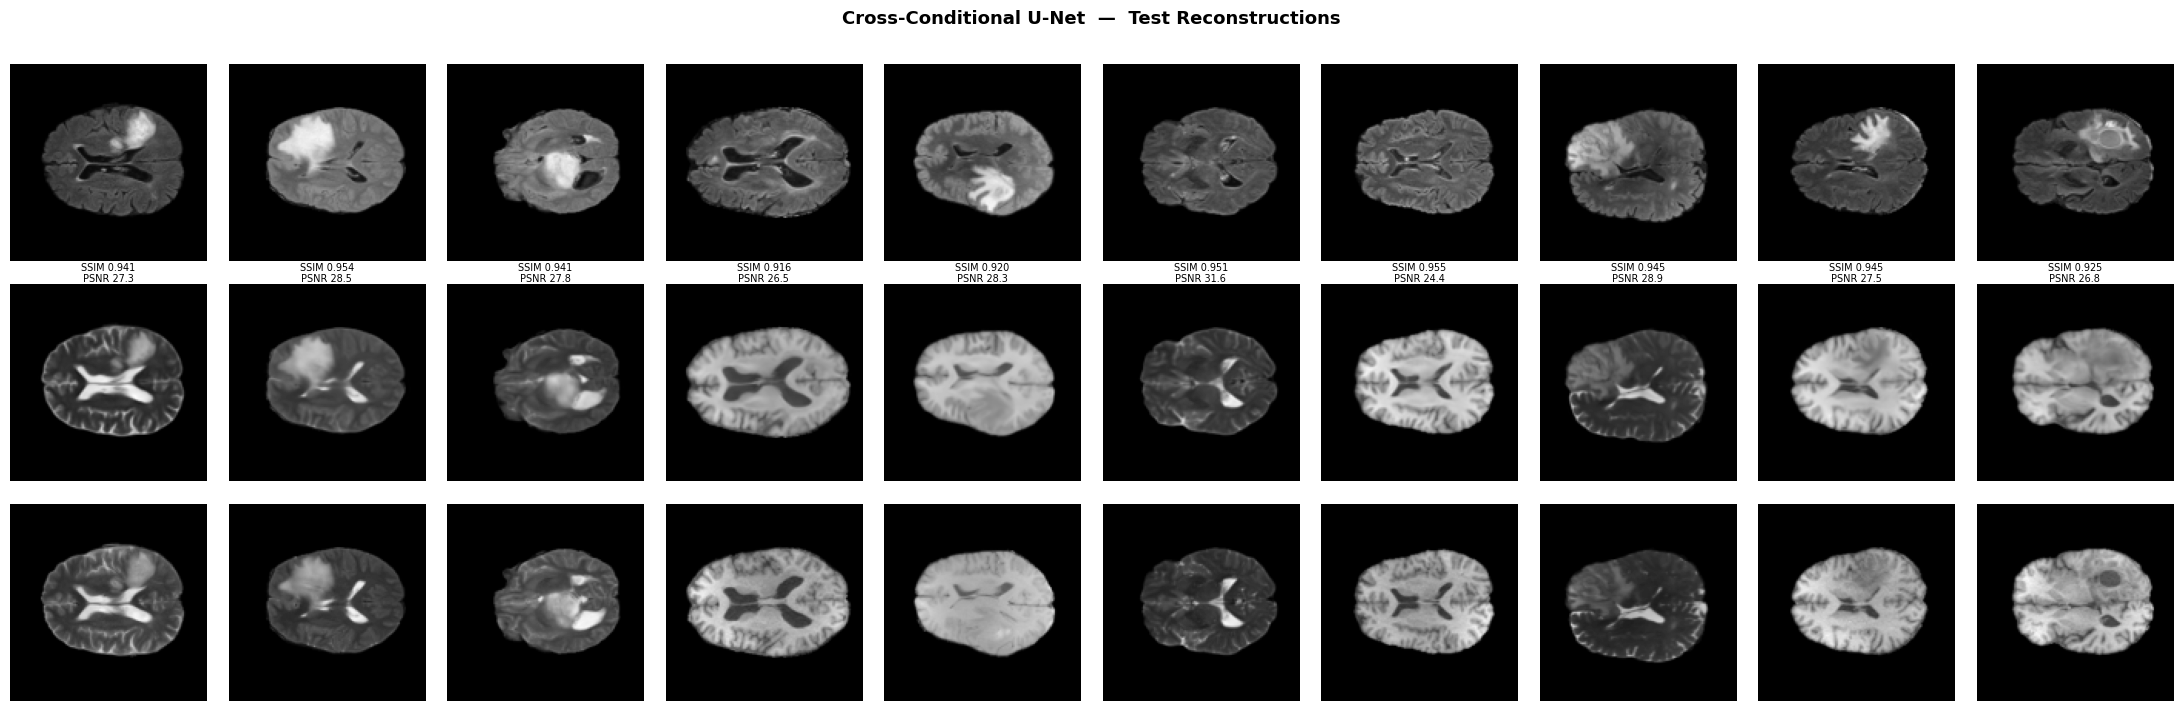

Saved → ./ccunet_outputs/test_reconstructions.png


In [12]:
from skimage.metrics import structural_similarity as sk_ssim
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
import matplotlib.pyplot as plt
# ── Load best checkpoint ──────────────────────────────────────────────────────
best_ckpt = torch.load(os.path.join(ckpt_dir, "best_unet.pt"), map_location=device)
model.load_state_dict(best_ckpt["model"])
model.eval()
print(f"Loaded best checkpoint — epoch {best_ckpt['epoch']}  val_loss={best_ckpt['best_loss']:.4f}")

# ── Full test-set metrics ─────────────────────────────────────────────────────
all_ssim, all_psnr, all_l1 = [], [], []

with torch.no_grad():
    for flair, target, emb in tqdm(test_loader, desc="Evaluating test set"):
        pred = model(flair.to(device), emb.to(device)).cpu()

        pred_np   = ((pred   + 1) / 2).clamp(0, 1).numpy()  # (B,1,H,W) → [0,1]
        target_np = ((target + 1) / 2).clamp(0, 1).numpy()

        for p, t in zip(pred_np, target_np):
            p, t = p[0], t[0]   # (H, W)
            all_ssim.append(sk_ssim(t, p, data_range=1.0))
            all_psnr.append(sk_psnr(t, p, data_range=1.0))
            all_l1.append(float(abs(p - t).mean()))

ssim_t = torch.tensor(all_ssim)
psnr_t = torch.tensor(all_psnr)
l1_t   = torch.tensor(all_l1)

print(f"\n── Test Set Results (N={len(all_ssim)} slices) ──────────────────")
print(f"  SSIM  :  {ssim_t.mean():.4f}  ±  {ssim_t.std():.4f}")
print(f"  PSNR  :  {psnr_t.mean():.2f} dB  ±  {psnr_t.std():.2f}")
print(f"  L1    :  {l1_t.mean():.4f}  ±  {l1_t.std():.4f}")

# ── Collect 10 samples for visualisation ─────────────────────────────────────
# Draw a fresh random batch from the test set
sample_loader = DataLoader(test_dataset, batch_size=16, shuffle=True, num_workers=0)
sample_flair, sample_target, sample_emb = next(iter(sample_loader))

with torch.no_grad():
    sample_pred = model(sample_flair.to(device), sample_emb.to(device)).cpu()

def to_np(t):
    """Denormalise [-1,1] → [0,1] and squeeze to (B, H, W) numpy."""
    return ((t + 1) / 2).clamp(0, 1).squeeze(1).numpy()

flairs  = to_np(sample_flair[:10])
preds   = to_np(sample_pred[:10])
targets = to_np(sample_target[:10])

sample_metrics = [
    (sk_ssim(targets[i], preds[i], data_range=1.0),
     sk_psnr(targets[i], preds[i], data_range=1.0))
    for i in range(10)
]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(22, 7))
fig.suptitle("Cross-Conditional U-Net  —  Test Reconstructions",
             fontsize=13, fontweight="bold", y=1.01)

row_labels = ["FLAIR (input)", "Prediction", "Ground Truth"]
for row, (imgs, label) in enumerate(zip([flairs, preds, targets], row_labels)):
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight="bold")
    for col in range(10):
        ax = axes[row, col]
        ax.imshow(imgs[col], cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if row == 1:
            s, p = sample_metrics[col]
            ax.set_title(f"SSIM {s:.3f}\nPSNR {p:.1f}", fontsize=7, pad=2)

plt.tight_layout()
save_path = os.path.join(CFG["output_dir"], "test_reconstructions.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")

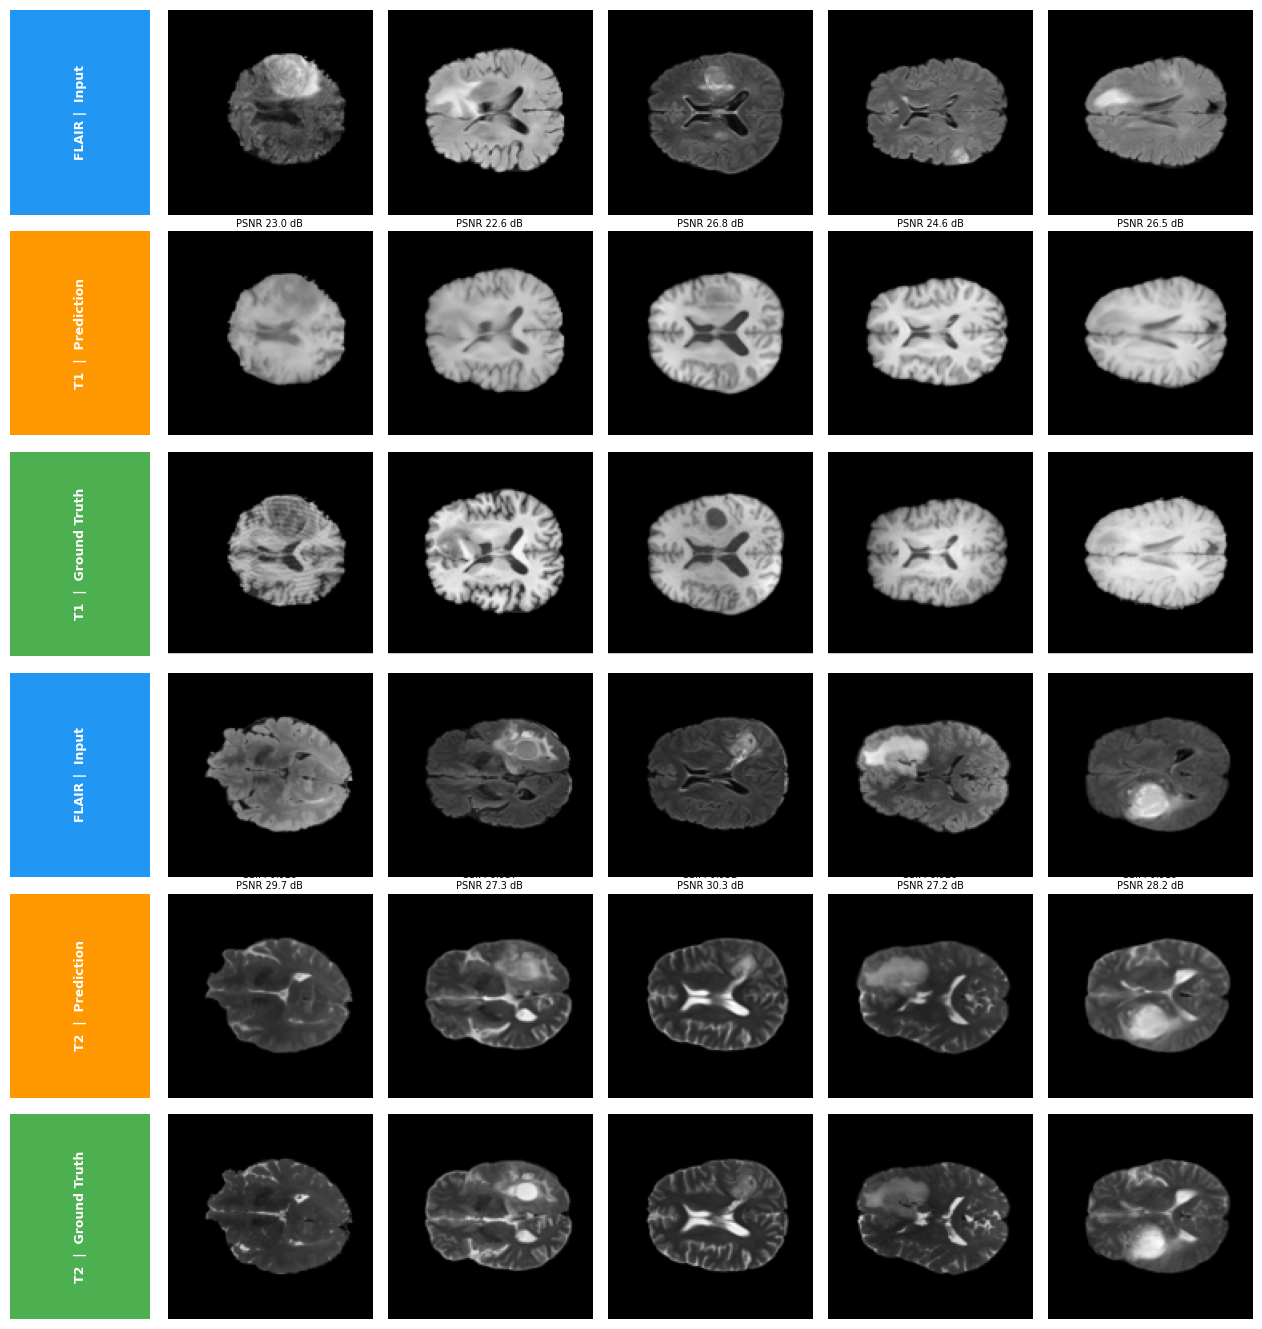

Saved → ./ccunet_outputs/t1_t2_reconstructions.png


In [16]:
import matplotlib.patches as mpatches

ds_t1_test = test_dataset.datasets[0]
ds_t2_test = test_dataset.datasets[1]

def get_samples(dataset, n=5):
    indices   = torch.randperm(len(dataset))[:n]
    flairs_t  = torch.stack([dataset[i][0] for i in indices])
    targets_t = torch.stack([dataset[i][1] for i in indices])
    embs_t    = torch.stack([dataset[i][2] for i in indices])
    with torch.no_grad():
        preds_t = model(flairs_t.to(device), embs_t.to(device)).cpu()
    return to_np(flairs_t), to_np(preds_t), to_np(targets_t)

def compute_metrics(preds, targets):
    return [(sk_ssim(targets[i], preds[i], data_range=1.0),
             sk_psnr(targets[i], preds[i], data_range=1.0))
            for i in range(len(preds))]

model.eval()
flairs_t1, preds_t1, targets_t1 = get_samples(ds_t1_test, n=5)
flairs_t2, preds_t2, targets_t2 = get_samples(ds_t2_test, n=5)
metrics_t1 = compute_metrics(preds_t1, targets_t1)
metrics_t2 = compute_metrics(preds_t2, targets_t2)

# ── Layout: 6 rows × 5 image cols, label drawn via fig.text ──────────────────
fig, axes = plt.subplots(6, 5, figsize=(14, 17))
plt.subplots_adjust(hspace=0.08, wspace=0.04,
                    left=0.12)   # leave room on left for labels

row_configs = [
    (0, flairs_t1,  "FLAIR |  Input",        "#2196F3",  None),
    (1, preds_t1,   "T1  |  Prediction",   "#FF9800",  metrics_t1),
    (2, targets_t1, "T1  |  Ground Truth", "#4CAF50",  None),
    (3, flairs_t2,  "FLAIR |  Input",        "#2196F3",  None),
    (4, preds_t2,   "T2  |  Prediction",   "#FF9800",  metrics_t2),
    (5, targets_t2, "T2  |  Ground Truth", "#4CAF50",  None),
]

for row_idx, imgs, label, color, metrics in row_configs:

    # Draw coloured label strip to the left of the row using the first axes
    ax0 = axes[row_idx, 0]
    # Get position of ax0 in figure coords
    pos = ax0.get_position()
    # Add a coloured rectangle just to the left of the row
    rect = mpatches.FancyBboxPatch(
        (pos.x0 - 0.11, pos.y0),        # x, y in figure coords
        0.10, pos.height,                # width, height
        boxstyle="square,pad=0",
        transform=fig.transFigure,
        facecolor=color, edgecolor="none",
        clip_on=False
    )
    fig.add_artist(rect)
    fig.text(
        pos.x0 - 0.06, pos.y0 + pos.height / 2,
        label,
        ha="center", va="center",
        fontsize=9, fontweight="bold", color="white",
        rotation=90,
        transform=fig.transFigure,
    )

    for col in range(5):
        ax = axes[row_idx, col]
        ax.imshow(imgs[col], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if metrics is not None:
            s, p = metrics[col]
            ax.set_title(f"SSIM {s:.3f}\nPSNR {p:.1f} dB", fontsize=7, pad=3)

# Thick white line between T1 and T2 blocks
for col in range(5):
    axes[2, col].spines["bottom"].set_visible(True)
    axes[2, col].spines["bottom"].set_linewidth(4)
    axes[2, col].spines["bottom"].set_color("white")

save_path = os.path.join(CFG["output_dir"], "t1_t2_reconstructions.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")